In [1]:
# assign directory
import git
from pathlib import Path
import os
ROOT_DIR = Path(git.Repo('.', search_parent_directories=True).working_tree_dir)
os.chdir(os.path.join(ROOT_DIR, "utilities"))
# from transform import *
from transform_audio import *
# from plotting import *
os.chdir(os.path.join(ROOT_DIR, "dataset-preparation"))

respiratory_dir = os.path.join(ROOT_DIR, 'raw-data', 'respiratory')
data_dir  = os.path.join(respiratory_dir, 'trimmed_audio_files')
# iterate over files in that directory
file_list = [os.path.join(data_dir, filename) for filename in os.listdir(data_dir) if filename != ".DS_Store"]
file_names = os.listdir(data_dir)

In [2]:
# erblet
transform_list(erblet_file, file_list, file_names)

Computing and exporting coefficients:   0%|          | 0/824 [00:00<?, ?it/s]

In [3]:
# fourier
max_n = max(map(lambda f: len(wavfile.read(f)[1]), file_list))
transform_list(fft_file, file_list, file_names, n=max_n)

Computing and exporting coefficients:   0%|          | 0/824 [00:00<?, ?it/s]

In [4]:
# short-time fourier
transform_list(stft_file, file_list, file_names)

Computing and exporting coefficients:   0%|          | 0/824 [00:00<?, ?it/s]

In [2]:
# continuous wavelet
transform_list(cwt_file, file_list, file_names, low_freq=10, high_freq=20000, num_scales=30)

Computing and exporting coefficients:   0%|          | 0/824 [00:00<?, ?it/s]

## Banding

In [5]:
def visualize_bands(bands, title=""):
    plt.figure(figsize=(12, 2))
    colors = ['lightcoral', 'indianred']
    
    # Check if bands list is not empty
    if not bands:
        print(f"Warning: Cannot visualize bands for '{title}' because the band list is empty.")
        return

    for i, (start, end) in enumerate(bands):
        plt.broken_barh([(start, end - start)], (0, 1), facecolors=colors[i%2])
    
    plt.xlabel('Frequency Index')
    plt.ylabel('Bands')
    plt.title(title)
    plt.yticks([])
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

In [ ]:
# # usage template
# coefs_by_freq = load_coefs_by_freq(coefs_npz_path, *args, cache=True)
# bands = freq_band_groupings(coefs_npz_path, *args, cache=True)
# coef_groups = group_coefs_by_band(coefs_by_freq, bands)

In [7]:
# erblet
coefs_npz_path = os.path.join(respiratory_dir, 'transforms', 'erb_coefs.npz')
freqs_npy_path = os.path.join(respiratory_dir, 'transforms', 'erb_freqs.npy')

# TODO: standardize this
freqs = np.load(freqs_npy_path)
avg_lengths = np.zeros_like(freqs, dtype=int)
with np.load(coefs_npz_path, allow_pickle=True) as coefs_npz:
    for file in coefs_npz:
        avg_lengths += np.array([len(c) for c in coefs_npz[file]])
    avg_lengths //= len(coefs_npz)

# coefs_by_freq = load_coefs_by_freq(
#     coefs_npz_path, 
#     batch_size=22,
#     subsample_every=avg_lengths // 100,
#     debug=True,
#     cache=True
# )
bands = freq_band_groupings(
    coefs_npz_path,
    batch_size=22,
    subsample_every=avg_lengths // 100,
    presplit_depth=1,
    debug=True
)

[0, 22) ~ [22, 44): presplit
  [0, 11) ~ [11, 22): 0.27488, 0.0
    [0, 5) ~ [5, 11): 0.21854, 0.0
      [0, 2) ~ [2, 5): 0.11593, 0.0
        [0, 1) ~ [1, 2): 0.24916, 0.0
        [2, 3) ~ [3, 5): 0.12452, 0.0
          [3, 4) ~ [4, 5): 0.06615, 0.0
      [5, 8) ~ [8, 11): 0.13313, 0.0
        [5, 6) ~ [6, 8): 0.08667, 0.0
          [6, 7) ~ [7, 8): 0.04546, 7.413133647473235e-155
        [8, 9) ~ [9, 11): 0.05233, 6.739867430162489e-268
          [9, 10) ~ [10, 11): 0.03468, 4.9995881101396086e-89
    [11, 16) ~ [16, 22): 0.12060, 0.0
      [11, 13) ~ [13, 16): 0.06426, 0.0
        [11, 12) ~ [12, 13): 0.02656, 1.3209508131027004e-52
        [13, 14) ~ [14, 16): 0.03449, 7.1584582823948e-119
      [16, 19) ~ [19, 22): 0.06304, 0.0
        [16, 17) ~ [17, 19): 0.02594, 2.635650198511624e-66
        [19, 20) ~ [20, 22): 0.03401, 1.8302406100706173e-111
  [22, 33) ~ [33, 44): 0.09928, 0.0
    [22, 27) ~ [27, 33): 0.05421, 0.0
      [22, 24) ~ [24, 27): 0.03062, 5.156746862324645e-163
  

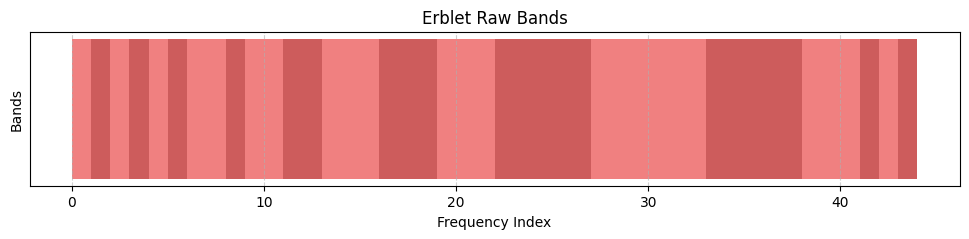

In [8]:
visualize_bands(bands, 'Erblet Raw Bands')

In [11]:
# short-time fourier
coefs_npz_path = os.path.join(respiratory_dir, 'transforms', 'stft_coefs.npz')

coefs_by_freq = load_coefs_by_freq(
    coefs_npz_path, 
    batch_size=None,
    subsample_every=10,
    debug=True,
    cache=True
)
bands = freq_band_groupings(
    coefs_npz_path,
    presplit_depth=1,
    debug=True,
    cache=True
)

[0, 256) ~ [256, 513): presplit
  [0, 128) ~ [128, 256): 0.12363, 0.0
    [0, 64) ~ [64, 128): 0.15989, 0.0
      [0, 32) ~ [32, 64): 0.19079, 0.0
        [0, 16) ~ [16, 32): 0.20576, 0.0
          [0, 8) ~ [8, 16): 0.21790, 0.0
            [0, 4) ~ [4, 8): 0.20573, 0.0
              [0, 2) ~ [2, 4): 0.12542, 0.0
                [0, 1) ~ [1, 2): 0.24984, 0.0
                [2, 3) ~ [3, 4): 0.10689, 0.0
              [4, 6) ~ [6, 8): 0.09264, 0.0
                [4, 5) ~ [5, 6): 0.06286, 0.0
                [6, 7) ~ [7, 8): 0.04081, 0.0
            [8, 12) ~ [12, 16): 0.06553, 0.0
              [8, 10) ~ [10, 12): 0.04215, 0.0
              [12, 14) ~ [14, 16): 0.02764, 0.0
          [16, 24) ~ [24, 32): 0.05951, 0.0
            [16, 20) ~ [20, 24): 0.03499, 0.0
            [24, 28) ~ [28, 32): 0.01666, 0.0
        [32, 48) ~ [48, 64): 0.05309, 0.0
          [32, 40) ~ [40, 48): 0.03889, 0.0
          [48, 56) ~ [56, 64): 0.01573, 0.0
      [64, 96) ~ [96, 128): 0.02988, 0.0
    [128, 

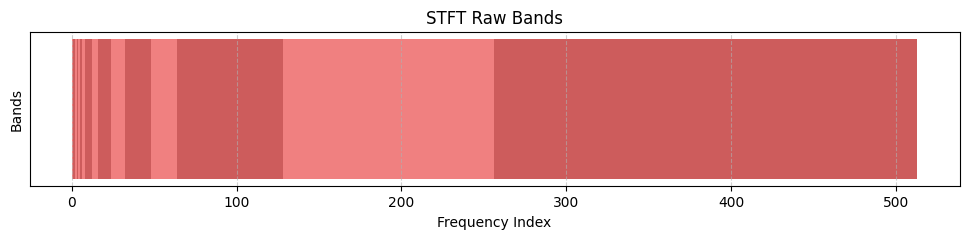

In [12]:
visualize_bands(bands, 'STFT Raw Bands')

In [3]:
# short-time fourier
coefs_npz_path = os.path.join(respiratory_dir, 'transforms', 'fft_coefs.npz')

# coefs_by_freq = load_coefs_by_freq(
#     coefs_npz_path, 
#     batch_size=None,
#     subsample_every=100,
#     debug=True,
#     cache=True
# )
bands = freq_band_groupings(
    coefs_npz_path,
    batch_size=None,
    subsample_every=100,
    presplit_depth=1,
    debug=True
)

[0, 146467) ~ [146467, 292934): presplit
  [0, 73233) ~ [73233, 146467): 0.14484, 0.0
    [0, 36616) ~ [36616, 73233): 0.17646, 0.0
      [0, 18308) ~ [18308, 36616): 0.20242, 0.0
        [0, 9154) ~ [9154, 18308): 0.21271, 0.0
          [0, 4577) ~ [4577, 9154): 0.20819, 0.0
            [0, 2288) ~ [2288, 4577): 0.19904, 0.0
              [0, 1144) ~ [1144, 2288): 0.16161, 2.3132051555005373e-222
                [0, 572) ~ [572, 1144): 0.11148, 5.176182589698205e-53
                  [0, 286) ~ [286, 572): 0.04422, 0.00014828424754358875
                  [572, 858) ~ [858, 1144): 0.05903, 8.708840215073761e-08
                    [572, 715) ~ [715, 858): 0.05060, 0.003959671315381793
                      [572, 643) ~ [643, 715): 0.03670, 0.37364680883342166
                      [715, 786) ~ [786, 858): 0.03329, 0.49611142971931343
                    [858, 1001) ~ [1001, 1144): 0.04607, 0.011474430360332
                [1144, 1716) ~ [1716, 2288): 0.06623, 5.82679597469776e-19
   

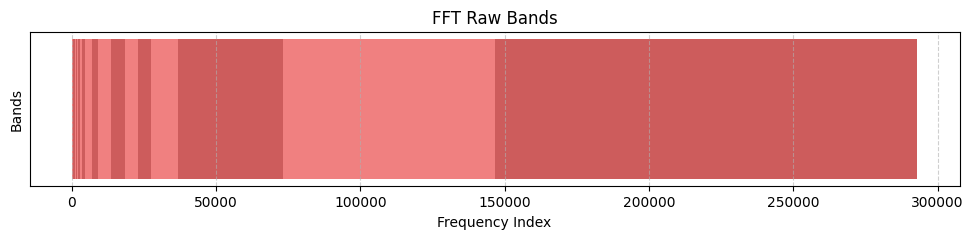

In [6]:
visualize_bands(bands, 'FFT Raw Bands')